# Parashikimi i Klinikes me te Afert me K-Nearest Neighbors (KNN)

Ky notebook perdor datasetin `dermatologist_in_Kosovo.csv` per te gjetur klinikat dermatologjike me te aferta nga nje lokacion i dhene nga perdoruesi.

Meqenese dataseti nuk ka etiketa klasifikimi, ketu perdorim algoritmin **K-Nearest Neighbors** si model per kerkim te fqinjeve me te afert (`NearestNeighbors`). Modeli trajnohet me koordinatat gjeografike (`latitude`, `longitude`) dhe perdor distancen **haversine**, e cila eshte e pershtatshme per pika ne glob.

### 1. Importimi i Bibliotekave

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_colwidth", 120)

### 2. Percaktimi i Folderave

In [3]:
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "dermatologist_in_Kosovo.csv")
MODEL_PATH = os.path.join(BASE_DIR, "clinic_knn_model.pkl")
DATA_CLEAN_PATH = os.path.join(BASE_DIR, "clinic_knn_clean_data.pkl")

print("Base directory:", BASE_DIR)
print("Dataset path:", DATA_PATH)

Base directory: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset
Dataset path: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset\dermatologist_in_Kosovo.csv


### 3. Ngarkimi dhe Kontrolli Fillestar i Datasetit

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Numri total i klinikave: {len(df)}")
print("Dimensioni i datasetit:", df.shape)
print("\nKolonat:")
print(df.columns.tolist())

df.head()

Numri total i klinikave: 20
Dimensioni i datasetit: (20, 10)

Kolonat:
['name', 'address', 'website', 'phone_number', 'reviews_count', 'reviews_average', 'latitude', 'longitude', 'category', 'location']


,name,address,website,phone_number,reviews_count,reviews_average,latitude,longitude,category,location
0,Bonsai Clinic,"22 Rruga Bajram Kelmendi, Prishtinë 10000",NaN,+383 49 288 433,NaN,4.9,42.663483,21.166109,dermatologist,Kosovo
1,Derma Line Klinika Dermatologjike & Estetike,"Arberi, Rr.Vicianum nr 186/7, Prishtinë 10000",NaN,+383 45 100 450,NaN,4.9,42.659687,21.149412,dermatologist,Kosovo
2,DermaD,"Afrim Vitia, 1 Svetozar Markoviq, Prishtinë 10000",NaN,+383 44 161 317,NaN,3.9,42.662514,21.167586,dermatologist,Kosovo
3,Anaderm Dermatologic & Cosmetic Clinic,"nr 50 Hilmi Rakovica, Prishtinë 10000",http://www.anadermks.com/,+383 44 300 298,NaN,4.3,42.654404,21.171287,dermatologist,Kosovo
4,"Ordinanca ""Pro-Derm""","Rruga B, Prishtinë 10000",NaN,+383 44 238 745,NaN,4.9,42.649209,21.173465,dermatologist,Kosovo


In [5]:
print("Informacion mbi datasetin:")
df.info()

print("\nVlerat qe mungojne per cdo kolone:")
print(df.isna().sum())

Informacion mbi datasetin:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             20 non-null     str    
 1   address          20 non-null     str    
 2   website          10 non-null     str    
 3   phone_number     17 non-null     str    
 4   reviews_count    2 non-null      float64
 5   reviews_average  20 non-null     float64
 6   latitude         20 non-null     float64
 7   longitude        20 non-null     float64
 8   category         20 non-null     str    
 9   location         20 non-null     str    
dtypes: float64(4), str(6)
memory usage: 1.7 KB

Vlerat qe mungojne per cdo kolone:
name                0
address             0
website            10
phone_number        3
reviews_count      18
reviews_average     0
latitude            0
longitude           0
category            0
location            0
dtype: int64


### 4. Pastrimi i te Dhenave

Per KNN ne kete rast duhen patjeter koordinatat. Rreshtat pa `latitude` ose `longitude` hiqen. Kolonat e vleresimit pastrohen per vizualizim dhe renditje, por modeli i afersise perdor vetem koordinatat.

In [6]:
clinic_df = df.copy()

clinic_df["reviews_count"] = clinic_df["reviews_count"].fillna(0)
clinic_df["reviews_average"] = clinic_df["reviews_average"].fillna(clinic_df["reviews_average"].median())
clinic_df["website"] = clinic_df["website"].fillna("Nuk ka website")
clinic_df["phone_number"] = clinic_df["phone_number"].fillna("Nuk ka numer")

clinic_df = clinic_df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
clinic_df["clinic_id"] = clinic_df.index

print(f"Klinika te vlefshme per KNN: {len(clinic_df)}")
clinic_df[["clinic_id", "name", "reviews_average", "reviews_count", "latitude", "longitude"]].head()

Klinika te vlefshme per KNN: 20


,clinic_id,name,reviews_average,reviews_count,latitude,longitude
0,0,Bonsai Clinic,4.9,0.0,42.663483,21.166109
1,1,Derma Line Klinika Dermatologjike & Estetike,4.9,0.0,42.659687,21.149412
2,2,DermaD,3.9,0.0,42.662514,21.167586
3,3,Anaderm Dermatologic & Cosmetic Clinic,4.3,0.0,42.654404,21.171287
4,4,"Ordinanca ""Pro-Derm""",4.9,0.0,42.649209,21.173465


### 5. Matrica e Korelacionit

Kjo matrice tregon lidhjen mes variablave numerike te datasetit. Vlerat afer `1` tregojne korelacion pozitiv, vlerat afer `-1` korelacion negativ, ndersa vlerat afer `0` tregojne pak ose aspak lidhje lineare.


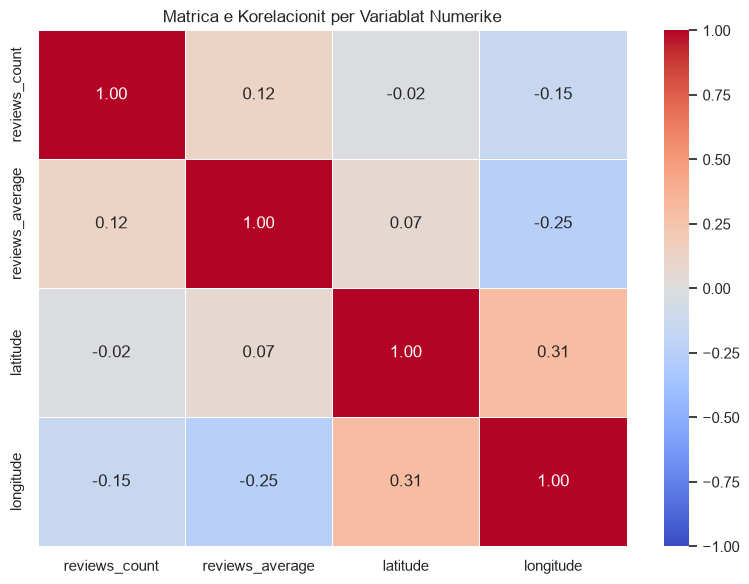

In [7]:
numeric_cols = ["reviews_count", "reviews_average", "latitude", "longitude"]
corr_matrix = clinic_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Matrica e Korelacionit per Variablat Numerike")
plt.tight_layout()
plt.show()


### 6. Vizualizimi i Lokacioneve te Klinikave

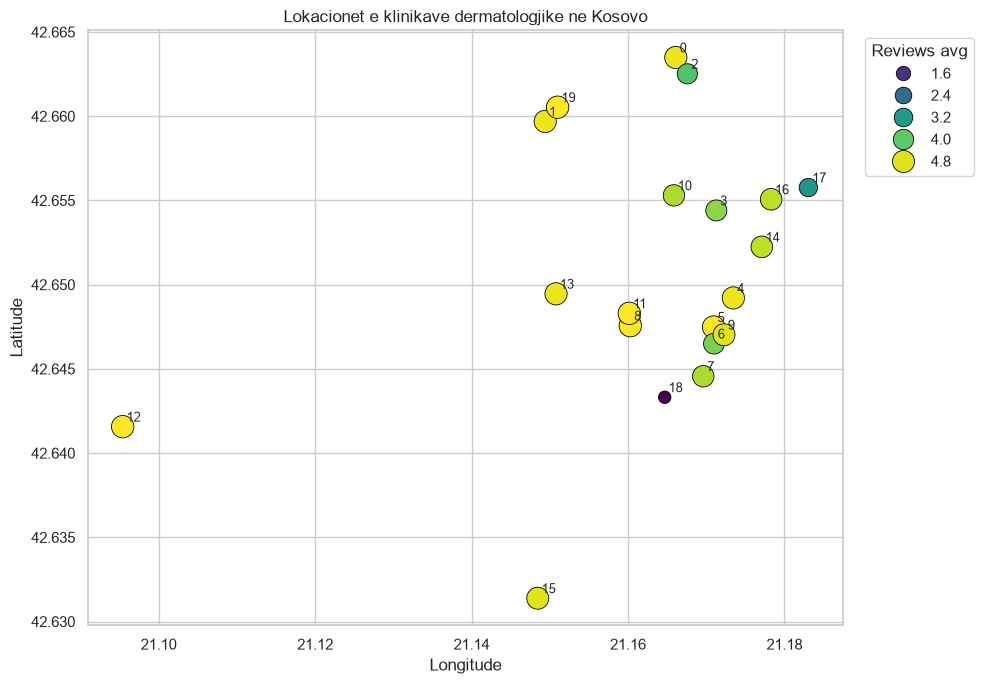

In [8]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=clinic_df,
    x="longitude",
    y="latitude",
    size="reviews_average",
    hue="reviews_average",
    sizes=(80, 260),
    palette="viridis",
    edgecolor="black",
    linewidth=0.6,
)

for _, row in clinic_df.iterrows():
    plt.text(row["longitude"] + 0.0005, row["latitude"] + 0.0003, str(row["clinic_id"]), fontsize=9)

plt.title("Lokacionet e klinikave dermatologjike ne Kosovo")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Reviews avg", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

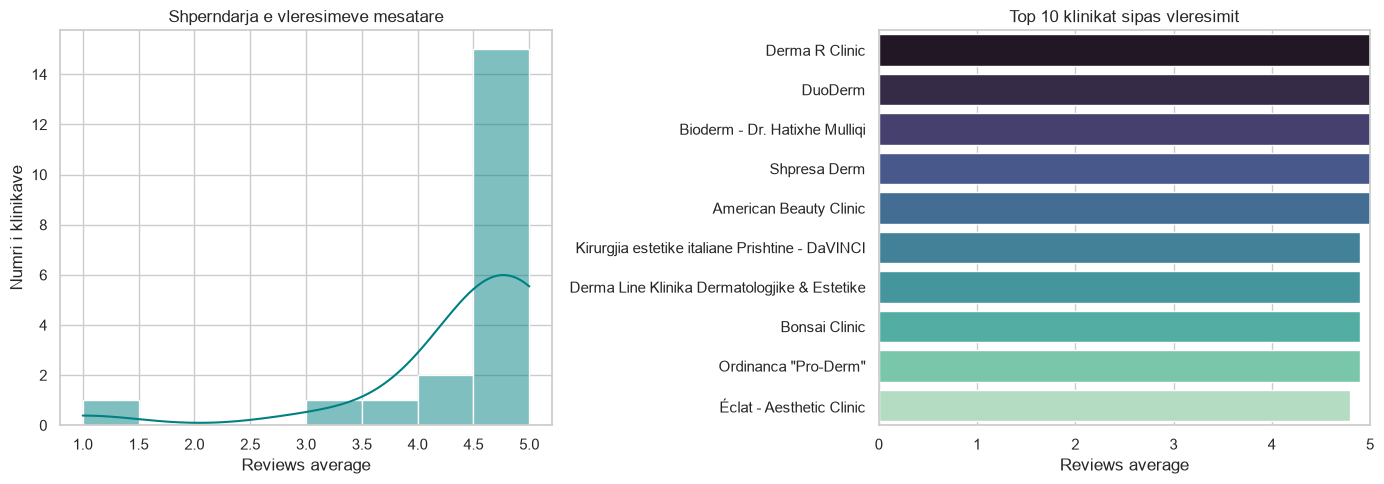

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(clinic_df["reviews_average"], bins=8, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Shperndarja e vleresimeve mesatare")
axes[0].set_xlabel("Reviews average")
axes[0].set_ylabel("Numri i klinikave")

rating_order = clinic_df.sort_values("reviews_average", ascending=False).head(10)
sns.barplot(data=rating_order, y="name", x="reviews_average", hue="name", ax=axes[1], palette="mako", legend=False)
axes[1].set_title("Top 10 klinikat sipas vleresimit")
axes[1].set_xlabel("Reviews average")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

### 7. Pergatitja e Karakteristikave per KNN

`NearestNeighbors` me metric `haversine` pret koordinatat ne radiane. Distancat qe kthen modeli jane ne radiane, prandaj i shumezojme me rrezen mesatare te Tokes per t'i kthyer ne kilometra.

In [10]:
EARTH_RADIUS_KM = 6371.0088

coordinate_cols = ["latitude", "longitude"]
X = np.radians(clinic_df[coordinate_cols].to_numpy())

print(f"Dimensioni i matrices se inputit X: {X.shape}")
print("Kolonat e perdorura:", coordinate_cols)

Dimensioni i matrices se inputit X: (20, 2)
Kolonat e perdorura: ['latitude', 'longitude']


### 8. Trajnimi i Modelit KNN per Kliniken me te Afert

In [11]:
k_neighbors = min(5, len(clinic_df))

knn_model = NearestNeighbors(
    n_neighbors=k_neighbors,
    algorithm="ball_tree",
    metric="haversine",
)
knn_model.fit(X)

print(f"Modeli KNN u trajnua me K={k_neighbors} fqinje.")

Modeli KNN u trajnua me K=5 fqinje.


### 9. Funksioni per Parashikimin e Klinikave me te Aferta

In [12]:
def predict_nearest_clinics(user_latitude, user_longitude, top_n=5):
    # Kthen top_n klinikat me te aferta nga koordinatat e perdoruesit.
    top_n = min(top_n, len(clinic_df))
    user_location_rad = np.radians([[user_latitude, user_longitude]])

    distances_rad, indices = knn_model.kneighbors(user_location_rad, n_neighbors=top_n)
    distances_km = distances_rad[0] * EARTH_RADIUS_KM

    nearest = clinic_df.iloc[indices[0]].copy()
    nearest["distance_km"] = distances_km

    return nearest[[
        "name",
        "address",
        "phone_number",
        "website",
        "reviews_average",
        "reviews_count",
        "latitude",
        "longitude",
        "distance_km",
    ]].sort_values("distance_km").reset_index(drop=True)

### 10. Testim me nje Lokacion Shembull

Shembulli me poshte perdor koordinata afer qendres se Prishtines. Ndryshoni `USER_LATITUDE` dhe `USER_LONGITUDE` per te testuar nje lokacion tjeter.

In [13]:
USER_LATITUDE = 42.6629
USER_LONGITUDE = 21.1655
TOP_N = 5

nearest_clinics = predict_nearest_clinics(USER_LATITUDE, USER_LONGITUDE, top_n=TOP_N)

print(f"Lokacioni i perdoruesit: ({USER_LATITUDE}, {USER_LONGITUDE})")
print(f"\nTop {TOP_N} klinikat me te aferta:")
nearest_clinics

Lokacioni i perdoruesit: (42.6629, 21.1655)

Top 5 klinikat me te aferta:


,name,address,phone_number,website,reviews_average,reviews_count,latitude,longitude,distance_km
0,Bonsai Clinic,"22 Rruga Bajram Kelmendi, Prishtinë 10000",+383 49 288 433,Nuk ka website,4.9,0.0,42.663483,21.166109,0.081724
1,DermaD,"Afrim Vitia, 1 Svetozar Markoviq, Prishtinë 10000",+383 44 161 317,Nuk ka website,3.9,0.0,42.662514,21.167586,0.175880
2,DermaCare,"14 Ukë Bytyqi, Prishtina 10000",+383 44 761 000,http://www.dermacareks.com/,4.5,0.0,42.655298,21.165872,0.845820
3,Anaderm Dermatologic & Cosmetic Clinic,"nr 50 Hilmi Rakovica, Prishtinë 10000",+383 44 300 298,http://www.anadermks.com/,4.3,0.0,42.654404,21.171287,1.056646
4,American Beauty Clinic,"Agi Kos, Nr c2, Objekti 3, Rruga Vicianum, lokali4.1 2, Prishtinë 10000",+383 48 596 596,https://americanbeautyclinic.com/,5.0,10.0,42.660531,21.150995,1.214948


### 11. Vizualizimi i Rezultatit te Parashikimit

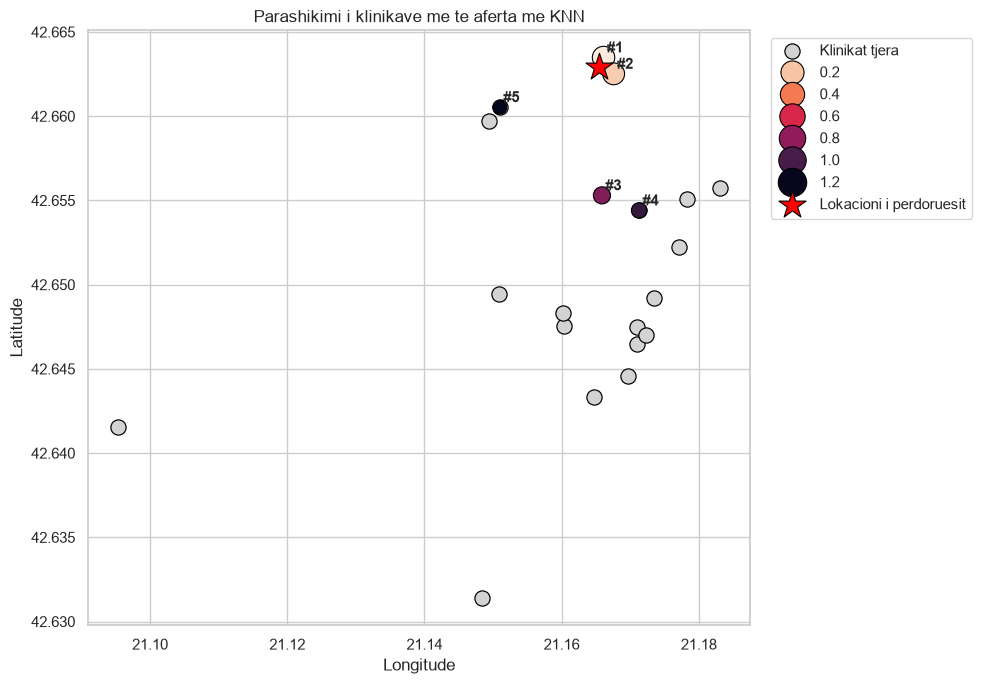

In [14]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=clinic_df,
    x="longitude",
    y="latitude",
    color="lightgray",
    s=120,
    edgecolor="black",
    label="Klinikat tjera",
)

nearest_plot = sns.scatterplot(
    data=nearest_clinics,
    x="longitude",
    y="latitude",
    hue="distance_km",
    size="distance_km",
    sizes=(260, 100),
    palette="rocket_r",
    edgecolor="black",
    linewidth=0.8,
    legend="brief",
)

plt.scatter(
    USER_LONGITUDE,
    USER_LATITUDE,
    marker="*",
    s=420,
    color="red",
    edgecolor="black",
    linewidth=0.8,
    label="Lokacioni i perdoruesit",
)

for rank, row in nearest_clinics.iterrows():
    plt.text(
        row["longitude"] + 0.0005,
        row["latitude"] + 0.0003,
        f"#{rank + 1}",
        fontsize=11,
        weight="bold",
    )

plt.title("Parashikimi i klinikave me te aferta me KNN")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


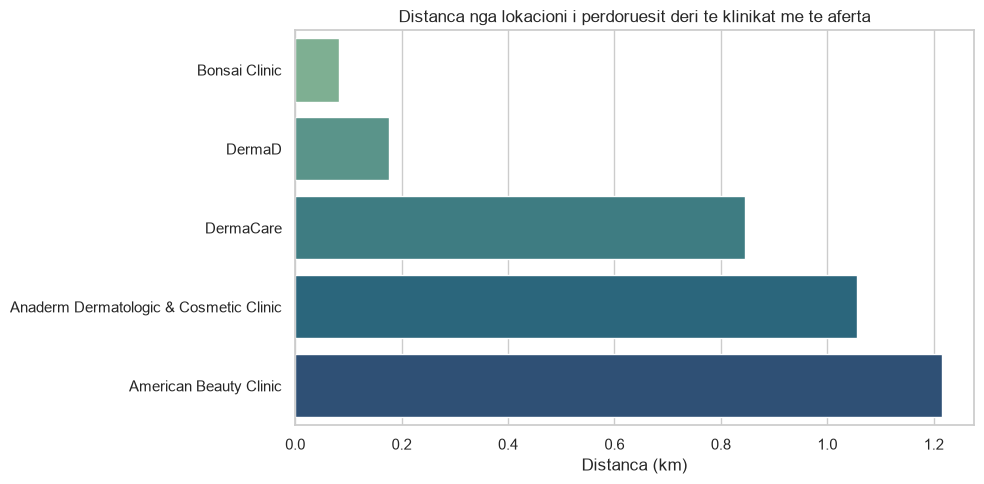

In [15]:
plt.figure(figsize=(10, 5))

plot_df = nearest_clinics.sort_values("distance_km", ascending=True)
sns.barplot(data=plot_df, y="name", x="distance_km", hue="name", palette="crest", legend=False)

plt.title("Distanca nga lokacioni i perdoruesit deri te klinikat me te aferta")
plt.xlabel("Distanca (km)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 12. Rekomandimi Final

In [16]:
best_clinic = nearest_clinics.iloc[0]

print("Klinika me e afert e parashikuar nga KNN:")
print(f"Emri: {best_clinic['name']}")
print(f"Adresa: {best_clinic['address']}")
print(f"Telefoni: {best_clinic['phone_number']}")
print(f"Website: {best_clinic['website']}")
print(f"Vleresimi mesatar: {best_clinic['reviews_average']}")
print(f"Distanca: {best_clinic['distance_km']:.3f} km")

Klinika me e afert e parashikuar nga KNN:
Emri: Bonsai Clinic
Adresa: 22 Rruga Bajram Kelmendi, Prishtinë 10000
Telefoni: +383 49 288 433
Website: Nuk ka website
Vleresimi mesatar: 4.9
Distanca: 0.082 km


### 13. Vleresimi me Confusion Matrix

Modeli kryesor perdor `NearestNeighbors`, prandaj nuk ka etiketa reale train/test si klasifikimi klasik. Per te matur saktesine, krijojme pika testuese sintetike afer cdo klinike dhe trajnojme nje `KNeighborsClassifier` qe parashikon `clinic_id`. Kjo tregon sa mire logjika KNN e ndan zonen rreth seciles klinike.


Accuracy ne test set sintetik: 0.9733

Raporti i klasifikimit:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         8
           5       0.86      0.86      0.86         7
           6       1.00      0.88      0.93         8
           7       1.00      1.00      1.00         8
           8       0.86      0.86      0.86         7
           9       0.89      1.00      0.94         8
          10       1.00      1.00      1.00         8
          11       0.86      0.86      0.86         7
          12       1.00      1.00      1.00         8
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.00         7
          16      

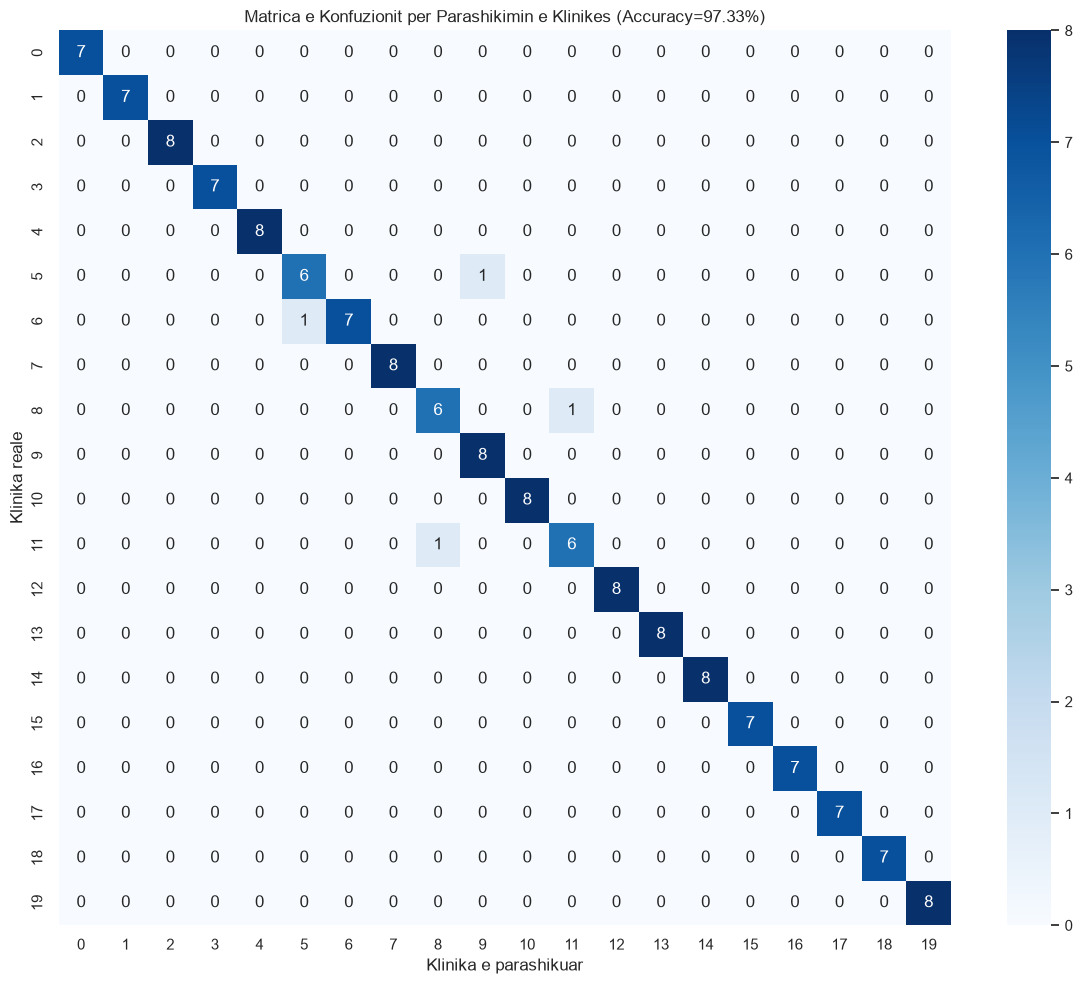

,clinic_id,name
0,0,Bonsai Clinic
1,1,Derma Line Klinika Dermatologjike & Estetike
2,2,DermaD
3,3,Anaderm Dermatologic & Cosmetic Clinic
4,4,"Ordinanca ""Pro-Derm"""
5,5,Shpresa Derm
6,6,Derma Plus
7,7,Derma ART
8,8,Bioderm - Dr. Hatixhe Mulliqi
9,9,Éclat - Aesthetic Clinic


In [17]:
rng = np.random.default_rng(42)
samples_per_clinic = 30
coordinate_noise = 0.00035

synthetic_rows = []
for _, clinic in clinic_df.iterrows():
    lat_samples = rng.normal(clinic["latitude"], coordinate_noise, samples_per_clinic)
    lon_samples = rng.normal(clinic["longitude"], coordinate_noise, samples_per_clinic)

    for lat, lon in zip(lat_samples, lon_samples):
        synthetic_rows.append({
            "latitude": lat,
            "longitude": lon,
            "clinic_id": clinic["clinic_id"],
        })

eval_df = pd.DataFrame(synthetic_rows)
X_eval = np.radians(eval_df[["latitude", "longitude"]].to_numpy())
y_eval = eval_df["clinic_id"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_eval,
    y_eval,
    test_size=0.25,
    random_state=42,
    stratify=y_eval,
)

classifier_model = KNeighborsClassifier(
    n_neighbors=3,
    algorithm="ball_tree",
    metric="haversine",
)
classifier_model.fit(X_train, y_train)
y_pred = classifier_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=clinic_df["clinic_id"])

print(f"Accuracy ne test set sintetik: {accuracy:.4f}")
print("\nRaporti i klasifikimit:")
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clinic_df["clinic_id"],
    yticklabels=clinic_df["clinic_id"],
)
plt.title(f"Matrica e Konfuzionit per Parashikimin e Klinikes (Accuracy={accuracy:.2%})")
plt.xlabel("Klinika e parashikuar")
plt.ylabel("Klinika reale")
plt.tight_layout()
plt.show()

clinic_df[["clinic_id", "name"]]


### 14. Ruajtja e Modelit dhe Datasetit te Pastruar

In [18]:
joblib.dump(knn_model, MODEL_PATH)
joblib.dump(clinic_df, DATA_CLEAN_PATH)

print(f"Modeli u ruajt ne: {MODEL_PATH}")
print(f"Dataseti i pastruar u ruajt ne: {DATA_CLEAN_PATH}")

Modeli u ruajt ne: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset\clinic_knn_model.pkl
Dataseti i pastruar u ruajt ne: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset\clinic_knn_clean_data.pkl
